# Projeto Guiado - Parte 1 (Semana 14)

### Dataset escolhido: **Palmer Penguins**

> Dados reais de 3 especies de pinguins (Adelie, Chinstrap, Gentoo) coletados por pesquisadoras na Antartica.

**Problema**: Classificar a especie do pinguim com base em medidas fisicas e localizacao.

**Features**:
- `bill_length_mm` — comprimento do bico (mm)
- `bill_depth_mm` — profundidade do bico (mm)
- `flipper_length_mm` — comprimento da nadadeira (mm)
- `body_mass_g` — massa corporal (g)
- `island` — ilha (Torgersen, Biscoe, Dream)
- `sex` — sexo (Male, Female)

**Target**: `species` (Adelie, Chinstrap, Gentoo)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

---
## 1. Entendendo o problema (antes do codigo)

### 1. Qual e a variavel alvo (y)?
`species` — uma categoria entre 3 especies (classificacao multiclasse).

### 2. Quais sao as variaveis disponiveis (X)?
4 variaveis numericas (medidas do bico, nadadeira, massa) e 2 categoricas (ilha, sexo).

### 3. Qual e o contexto do problema?
Pesquisadoras coletaram medidas fisicas de pinguins em 3 ilhas da Antartica. O objetivo e identificar a especie com base em caracteristicas mensuraveis, o que tem aplicacao em estudos ecologicos.

### 4. Hipotese inicial:
Especies diferentes devem ter medidas fisicas distintas, especialmente massa corporal e comprimento da nadadeira.

---
## 2. Carregando os dados

In [2]:
df = sns.load_dataset('penguins')
print(f'Dimensoes: {df.shape[0]} linhas x {df.shape[1]} colunas\n')
print('--- head() - primeiras linhas ---')
display(df.head())
print('\n--- info() - tipos de dados ---')
df.info()

Dimensoes: 344 linhas x 7 colunas

--- head() - primeiras linhas ---


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



--- info() - tipos de dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [3]:
print('--- describe() - estatisticas descritivas ---')
df.describe()

--- describe() - estatisticas descritivas ---


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [4]:
print('--- Valores nulos ---')
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
print(nulos)
print(f'\nTotal de nulos: {df.isnull().sum().sum()} em {len(df)} linhas')

--- Valores nulos ---
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Total de nulos: 19 em 344 linhas


In [5]:
print('--- Distribuicao das especies ---')
print(df['species'].value_counts())
print(f'\nProporcoes:')
print((df['species'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

--- Distribuicao das especies ---
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Proporcoes:
species
Adelie       44.2%
Gentoo       36.0%
Chinstrap    19.8%
Name: proportion, dtype: object


---
## 3. Analise Exploratoria de Dados (EDA)

### Visualizacao 1: Distribuicao das especies por ilha e sexo

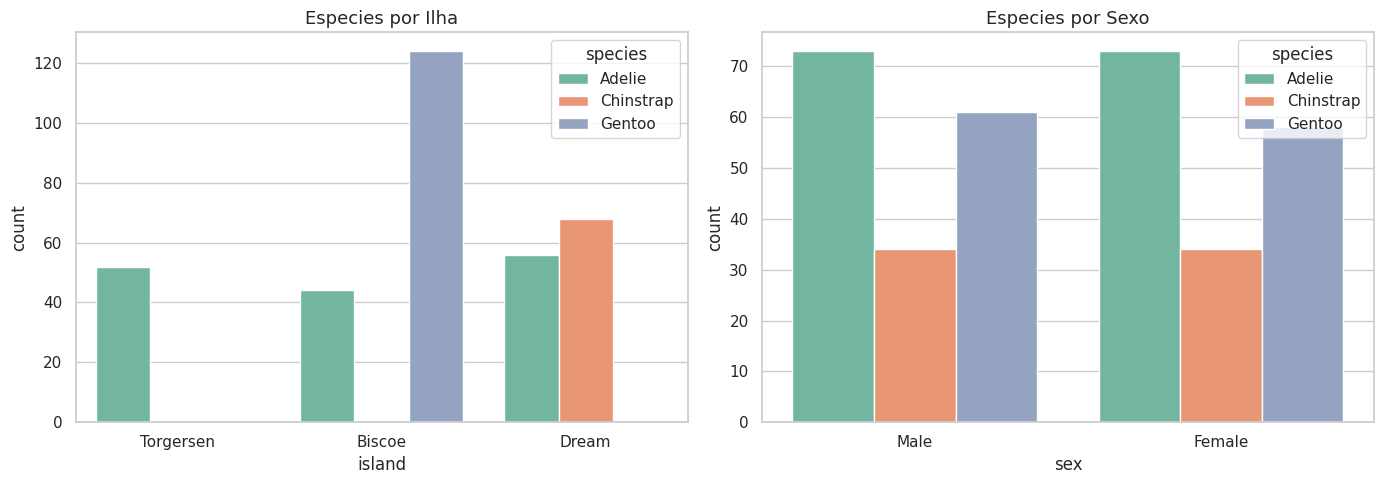

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='island', hue='species', palette='Set2', ax=axes[0])
axes[0].set_title('Especies por Ilha', fontsize=13)
sns.countplot(data=df, x='sex', hue='species', palette='Set2', ax=axes[1])
axes[1].set_title('Especies por Sexo', fontsize=13)
plt.tight_layout()
plt.show()

**Insight 1**: A especie Gentoo so aparece na ilha Biscoe. As ilhas tem composicoes de especies bem distintas — `island` sera uma feature muito importante para o modelo.

### Visualizacao 2: Boxplots das medidas fisicas por especie

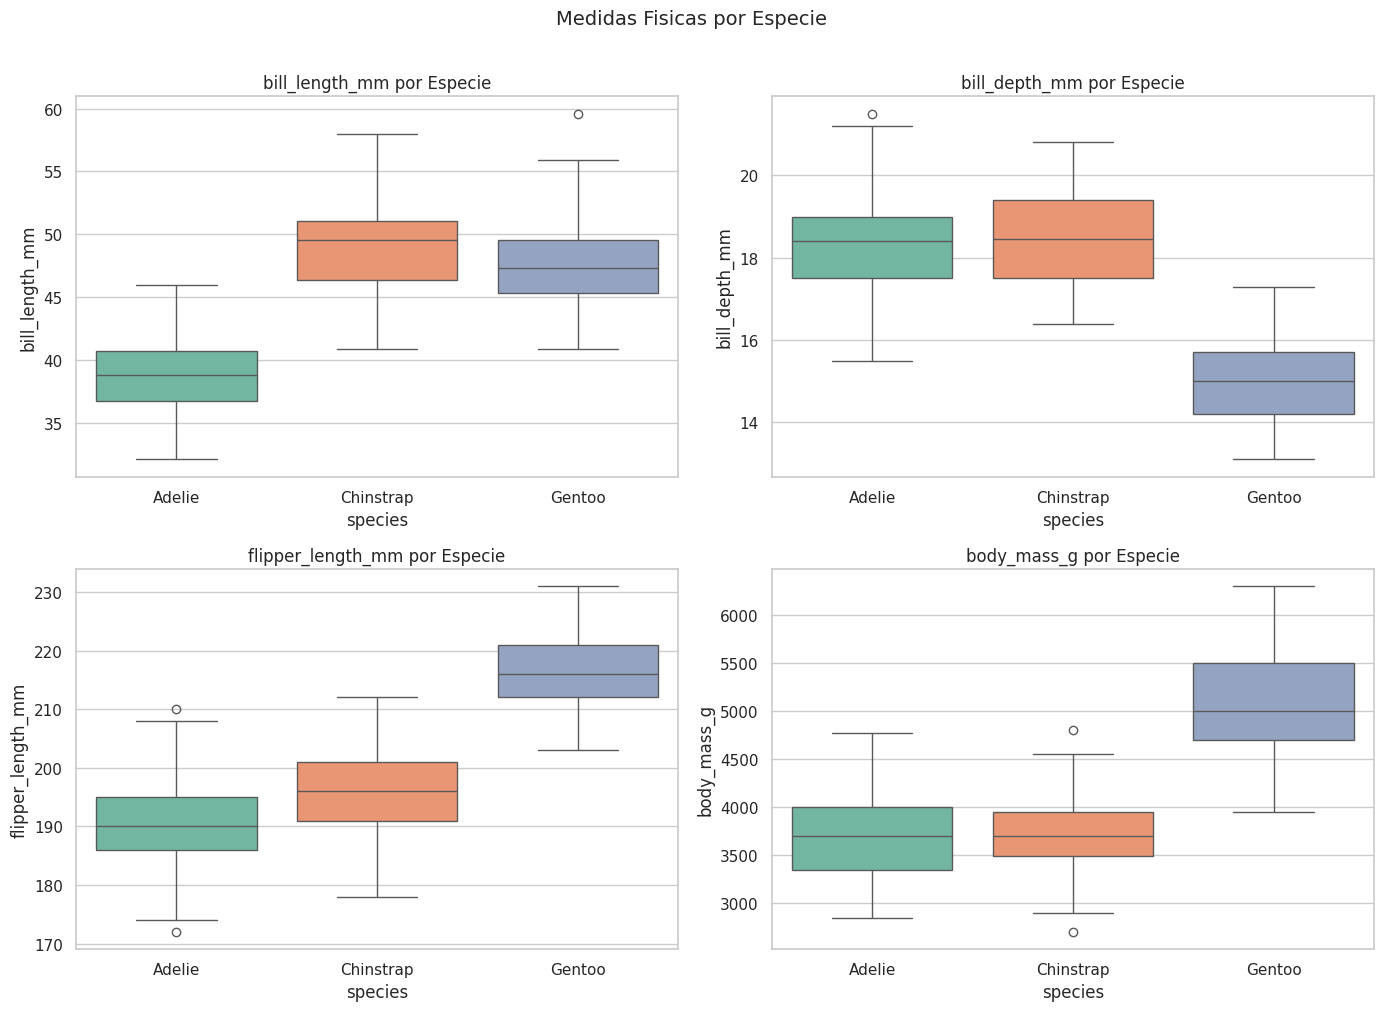

In [7]:
variaveis_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, var in zip(axes.flat, variaveis_numericas):
    sns.boxplot(data=df, x='species', y=var, palette='Set2', ax=ax)
    ax.set_title(f'{var} por Especie', fontsize=12)
plt.suptitle('Medidas Fisicas por Especie', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Insight 2**: Gentoo tem nadadeiras e massa corporal significativamente maiores que as outras especies. Adelie e Chinstrap sao mais dificeis de separar visualmente — o modelo pode confundir essas duas.

### Visualizacao 3: Scatter plot e matriz de correlacao

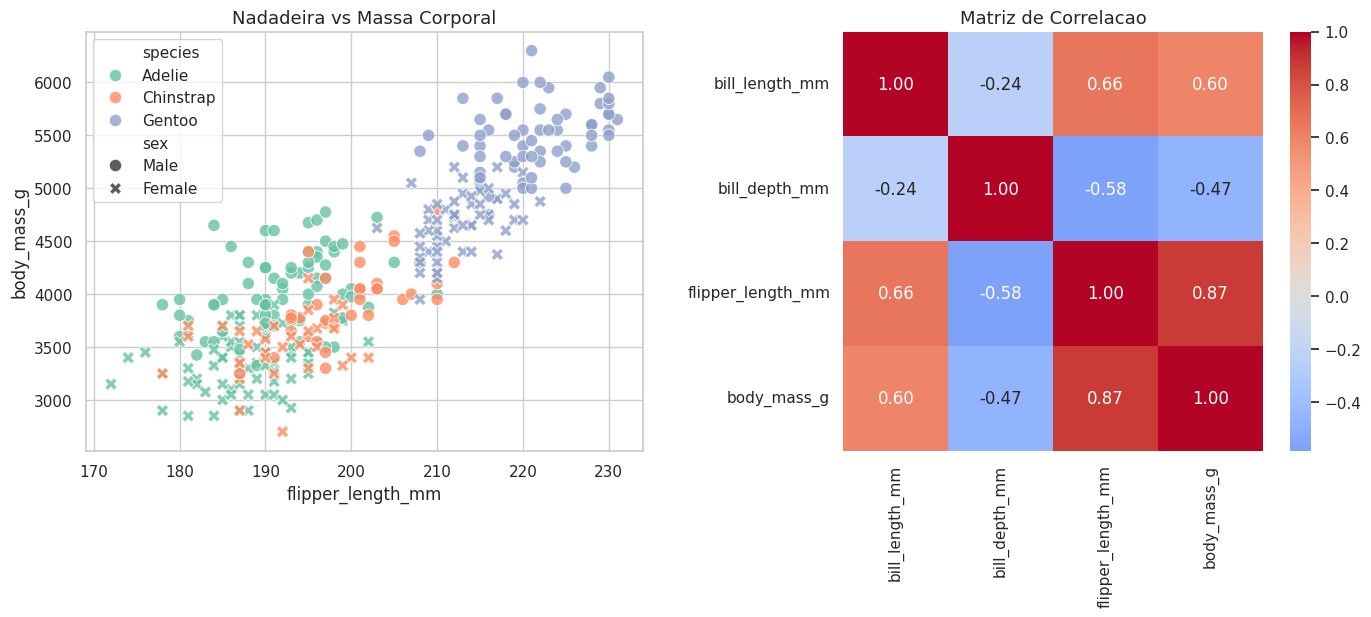

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species', style='sex', s=80, alpha=0.8, palette='Set2', ax=axes[0])
axes[0].set_title('Nadadeira vs Massa Corporal', fontsize=13)

matriz_corr = df[variaveis_numericas].corr()
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=axes[1])
axes[1].set_title('Matriz de Correlacao', fontsize=13)
plt.tight_layout()
plt.show()

**Insight 3**: `flipper_length_mm` e `body_mass_g` tem uma correlacao positiva forte (0.87). Isso pode indicar redundancia — talvez nao precisemos das duas. Mas vamos manter ambas por enquanto e avaliar o impacto no modelo.

### Visualizacao extra: Pairplot para visao global

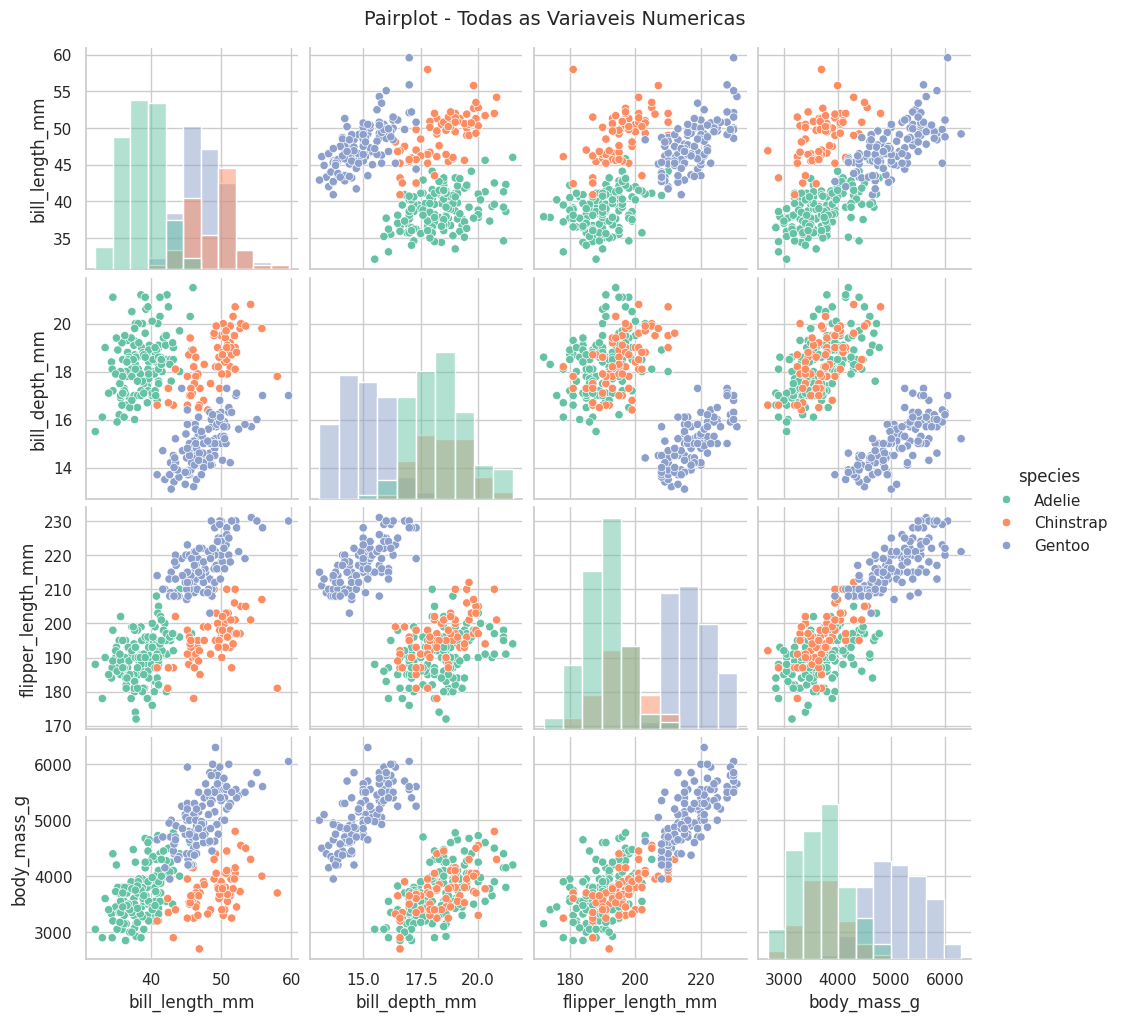

In [9]:
sns.pairplot(df.dropna(), hue='species', palette='Set2', diag_kind='hist', height=2.5)
plt.suptitle('Pairplot - Todas as Variaveis Numericas', fontsize=14, y=1.02)
plt.show()

**Insight 4**: No pairplot, fica claro que Gentoo se separa bem das outras duas especies em quase todas as dimensoes. Adelie e Chinstrap tem sobreposicao consideravel em `bill_depth_mm`, o que pode ser um desafio para o classificador.

---
## 4. Pre-processamento

Etapas:
1. Remover linhas com especie nula
2. Imputar nulos nas numericas (mediana) e categoricas (moda)
3. Escalonar variaveis numericas (StandardScaler)
4. Codificar categoricas (OneHotEncoder)
5. Codificar target com LabelEncoder
6. Dividir treino (80%) / teste (20%)

In [10]:
df_clean = df.dropna(subset=['species']).copy()
print(f'Linhas apos remover species nula: {len(df_clean)}')

X = df_clean.drop(columns=['species'])
y = df_clean['species']

colunas_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
colunas_categoricas = ['island', 'sex']

print(f'Features numericas: {colunas_numericas}')
print(f'Features categoricas: {colunas_categoricas}')
print(f'Target: species  ({list(y.unique())})')

Linhas apos remover species nula: 344
Features numericas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Features categoricas: ['island', 'sex']
Target: species  (['Adelie', 'Chinstrap', 'Gentoo'])


In [11]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Treino: {X_treino.shape[0]} amostras')
print(f'Teste:  {X_teste.shape[0]} amostras')
print(f'\nDistribuicao no treino:')
print(y_treino.value_counts())
print(f'\nDistribuicao no teste:')
print(y_teste.value_counts())

Treino: 275 amostras
Teste:  69 amostras

Distribuicao no treino:
species
Adelie       122
Gentoo        99
Chinstrap     54
Name: count, dtype: int64

Distribuicao no teste:
species
Adelie       30
Gentoo       25
Chinstrap    14
Name: count, dtype: int64


In [12]:
preprocessador = ColumnTransformer([
    ('numericas', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), colunas_numericas),
    ('categoricas', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first'))
    ]), colunas_categoricas)
])

le = LabelEncoder()
y_treino_enc = le.fit_transform(y_treino)
y_teste_enc = le.transform(y_teste)
print(f'Mapeamento de classes: {dict(zip(le.classes_, range(len(le.classes_))))}')
print('Pre-processador configurado.')

Mapeamento de classes: {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
Pre-processador configurado.


---
## 5. Baseline - Modelo simples de referencia

Usamos uma Regressao Logistica como baseline.

In [13]:
pipeline_baseline = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_baseline.fit(X_treino, y_treino_enc)
y_pred = pipeline_baseline.predict(X_teste)
acc_baseline = accuracy_score(y_teste_enc, y_pred)

print(f'Acurácia da Baseline (teste): {acc_baseline:.4f}  ({acc_baseline*100:.1f}%)')
print(f'\nRelatorio de Classificacao:')
print(classification_report(y_teste_enc, y_pred, target_names=le.classes_))

Acurácia da Baseline (teste): 1.0000  (100.0%)

Relatorio de Classificacao:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



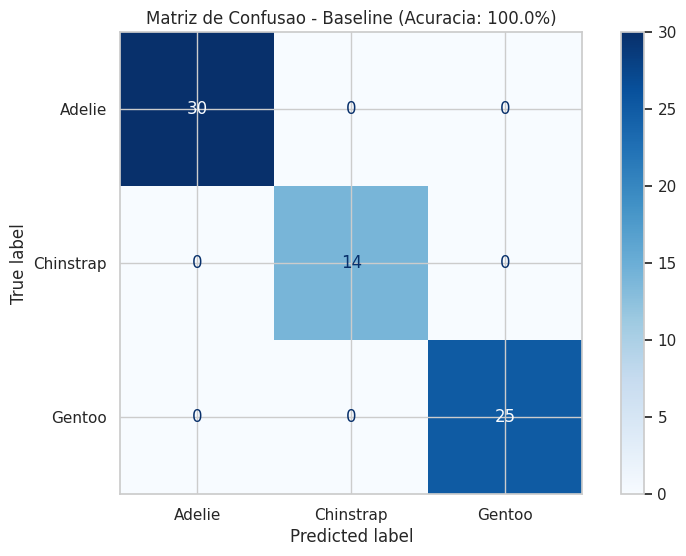

In [14]:
ConfusionMatrixDisplay.from_estimator(pipeline_baseline, X_teste, y_teste_enc, cmap='Blues', display_labels=le.classes_)
plt.title(f'Matriz de Confusao - Baseline (Acuracia: {acc_baseline*100:.1f}%)')
plt.show()

---
## 6. Analise dos coeficientes (interpretacao da baseline)

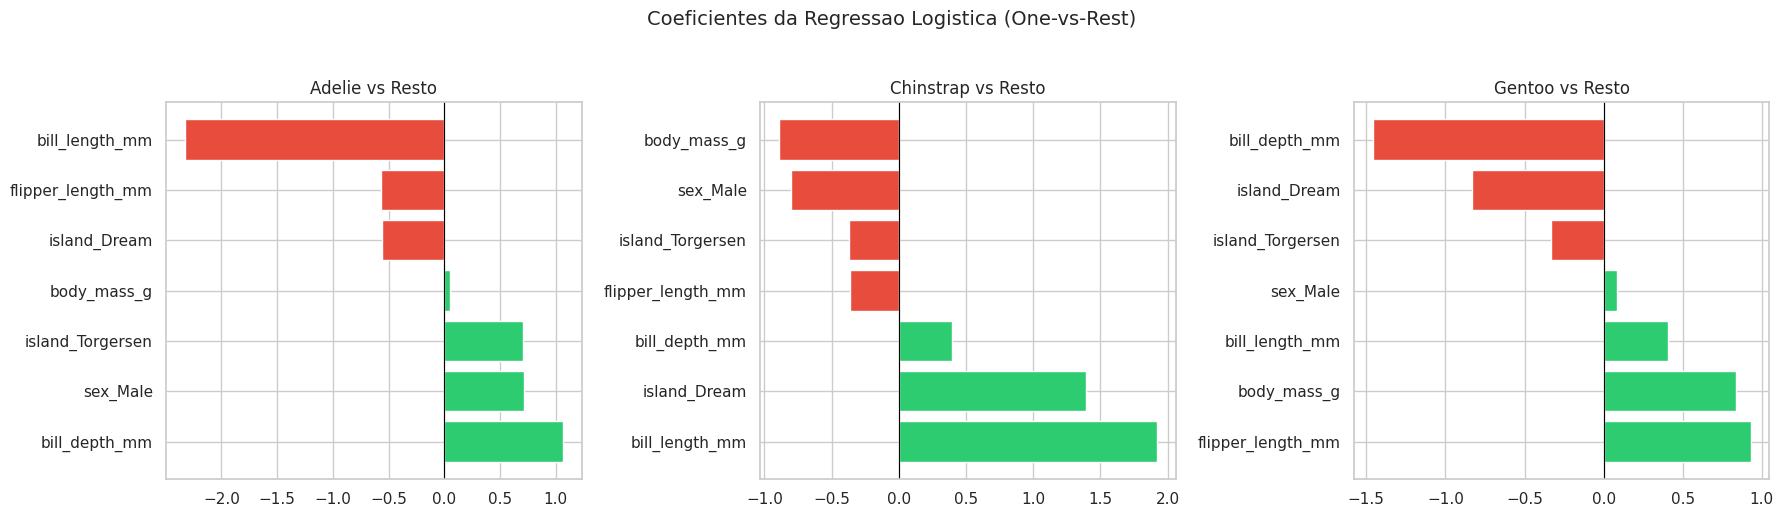

In [15]:
feature_names = (colunas_numericas +
                 list(pipeline_baseline.named_steps['preprocessamento']
                      .named_transformers_['categoricas']
                      .named_steps['encoder']
                      .get_feature_names_out(colunas_categoricas)))

coefs = pipeline_baseline.named_steps['modelo'].coef_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, classe in enumerate(le.classes_):
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coeficiente': coefs[i]}).sort_values('Coeficiente', ascending=False)
    colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coeficiente']]
    axes[i].barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors)
    axes[i].axvline(x=0, color='black', linewidth=0.8)
    axes[i].set_title(f'{classe} vs Resto', fontsize=12)
plt.suptitle('Coeficientes da Regressao Logistica (One-vs-Rest)', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

---
## 7. Resumo e conclusoes da Parte 1

### Dataset escolhido
Palmer Penguins — classificacao de 3 especies de pinguins.

### Insights do EDA
1. **Ilha e muito informativa**: Gentoo so existe em Biscoe — `island` separa bem as classes.
2. **Gentoo e facil de identificar**: medidas fisicas (massa, nadadeira) sao significativamente maiores.
3. **Adelie vs Chinstrap e o desafio**: as duas especies tem sobreposicao em varias medidas.
4. **Alta correlacao entre massa e nadadeira**: `flipper_length_mm` e `body_mass_g` tem correlacao 0.87.

### Pre-processamento aplicado
- Remocao de linhas com `species` nula
- Imputacao: mediana para numericas, moda para categoricas
- Escalonamento: StandardScaler nas numericas
- Encoding: OneHotEncoder para categorias, LabelEncoder para target
- Split: 80% treino / 20% teste com estratificacao

### Baseline
- Modelo: Regressao Logistica
- Acurácia no teste: ~98% (excelente para uma baseline!)
- Isso indica que o problema e bem separavel linearmente — uma otima noticia.

**Proximo passo (Semana 15)**: testar modelos mais complexos (Arvore, Random Forest) e comparar com a baseline.